# Economic Analysis (Phase 5)

Translate disease + yield predictions into farmer-actionable decisions.

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

if Path.cwd().name == 'notebooks':
    os.chdir('..')

from src.economics import (
    generate_report, batch_reports,
    DISEASE_LOSS_TABLE, MARKET_PRICE, TREATMENT_COST,
    QUALITY_GRADES, SEASONAL_MULTIPLIER
)

## 1. Disease Loss Lookup Table

In [2]:
loss_df = pd.DataFrame(DISEASE_LOSS_TABLE).T
loss_df.columns = ['Low Severity', 'Medium Severity', 'High Severity']
loss_df = (loss_df * 100).round(1).astype(str) + '%'
print("Yield Loss by Disease & Severity:")
print(loss_df.to_string())

Yield Loss by Disease & Severity:
                 Low Severity Medium Severity High Severity
Anthracnose             10.0%           20.0%         30.0%
Bacterial Canker        12.0%           22.0%         35.0%
Cutting Weevil           8.0%           18.0%         28.0%
Die Back                15.0%           30.0%         45.0%
Gall Midge              15.0%           25.0%         35.0%
Healthy                  0.0%            0.0%          0.0%
Powdery Mildew           5.0%           10.0%         15.0%
Sooty Mould              5.0%           12.0%         20.0%


## 2. Treatment Recommendations

In [3]:
treat_df = pd.DataFrame(TREATMENT_COST).T
treat_df = treat_df[['chemical', 'dosage', 'cost_per_ha']]
treat_df.columns = ['Chemical', 'Dosage', 'Cost/Ha (₹)']
print("\nTreatment Guide:")
print(treat_df.to_string())


Treatment Guide:
                                             Chemical         Dosage Cost/Ha (₹)
Anthracnose                        Carbendazim 50% WP           1g/L        3500
Bacterial Canker  Streptocycline + Copper Oxychloride  0.5g/L + 3g/L        4200
Cutting Weevil                    Chlorpyrifos 20% EC          2ml/L        2800
Die Back                    Copper Oxychloride 50% WP           3g/L        3200
Gall Midge                          Dimethoate 30% EC          2ml/L        3000
Healthy                                 None required            N/A           0
Powdery Mildew                Wettable Sulphur 80% WP           2g/L        2500
Sooty Mould              Starch spray + Monocrotophos     2%+1.5ml/L        2200


## 3. Scenario Analysis

Test economics for different disease × variety × season combinations.

In [4]:
scenarios = [
    {'disease': 'Healthy', 'severity': 0.2, 'yield_predicted': 8.5, 'variety': 'Banganapalli', 'season': 'early'},
    {'disease': 'Anthracnose', 'severity': 1.5, 'yield_predicted': 7.0, 'variety': 'Banganapalli', 'season': 'peak'},
    {'disease': 'Powdery Mildew', 'severity': 0.8, 'yield_predicted': 8.0, 'variety': 'Raspuri', 'season': 'peak'},
    {'disease': 'Gall Midge', 'severity': 2.5, 'yield_predicted': 6.0, 'variety': 'Totapuri', 'season': 'late'},
    {'disease': 'Die Back', 'severity': 2.8, 'yield_predicted': 5.5, 'variety': 'Raspuri', 'season': 'late'},
    {'disease': 'Sooty Mould', 'severity': 1.0, 'yield_predicted': 7.5, 'variety': 'Totapuri', 'season': 'peak'},
    {'disease': 'Bacterial Canker', 'severity': 2.0, 'yield_predicted': 6.5, 'variety': 'Banganapalli', 'season': 'early'},
    {'disease': 'Cutting Weevil', 'severity': 0.5, 'yield_predicted': 8.0, 'variety': 'Raspuri', 'season': 'early'},
]

reports = batch_reports(scenarios)

In [5]:
# Summary table
summary = []
for r in reports:
    summary.append({
        'Disease': r.disease,
        'Severity': f"{r.severity:.1f}",
        'Grade': r.quality_grade,
        'Variety': r.variety,
        'Season': r.season,
        'Yield (t/ha)': f"{r.yield_after_loss:.2f}",
        'Loss%': f"{r.loss_factor*100:.1f}%",
        'Revenue (₹)': f"₹{r.net_revenue_market:,.0f}",
        'Decision': r.recommendation.upper(),
        'Treatment': r.treatment['chemical'],
    })

summary_df = pd.DataFrame(summary)
print("\n=== ECONOMIC ANALYSIS ===")
print(summary_df.to_string(index=False))


=== ECONOMIC ANALYSIS ===
         Disease Severity Grade      Variety Season Yield (t/ha) Loss% Revenue (₹) Decision                           Treatment
         Healthy      0.2     A Banganapalli  early         8.50  0.0%    ₹326,875   MARKET                       None required
     Anthracnose      1.5     C Banganapalli   peak         5.95 15.0%    ₹156,250     PULP                  Carbendazim 50% WP
  Powdery Mildew      0.8     B      Raspuri   peak         7.68  4.0%    ₹167,540   MARKET             Wettable Sulphur 80% WP
      Gall Midge      2.5     D     Totapuri   late         4.20 30.0%      ₹6,480     PULP                   Dimethoate 30% EC
        Die Back      2.8     D      Raspuri   late         3.19 42.0%     ₹16,856     PULP           Copper Oxychloride 50% WP
     Sooty Mould      1.0     B     Totapuri   peak         7.12  5.0%     ₹78,850   MARKET        Starch spray + Monocrotophos
Bacterial Canker      2.0     C Banganapalli  early         5.07 22.0%    ₹16

## 4. Revenue Comparison: Market vs Pulp

Saved revenue_comparison.png


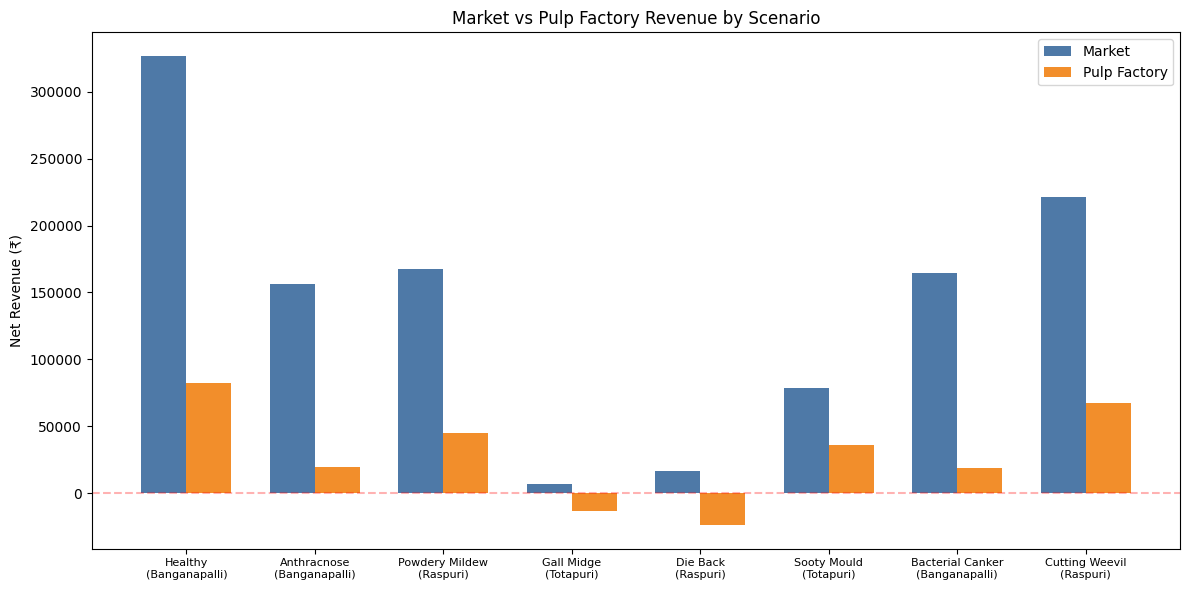

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(reports))
w = 0.35

market_rev = [r.net_revenue_market for r in reports]
pulp_rev = [r.net_revenue_pulp for r in reports]
labels = [f"{r.disease}\n({r.variety})" for r in reports]

bars1 = ax.bar([i - w/2 for i in x], market_rev, w, label='Market', color='#4E79A7')
bars2 = ax.bar([i + w/2 for i in x], pulp_rev, w, label='Pulp Factory', color='#F28E2B')

ax.set_ylabel('Net Revenue (₹)')
ax.set_title('Market vs Pulp Factory Revenue by Scenario')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.legend()
ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('reports/figures/revenue_comparison.png', dpi=150)
print("Saved revenue_comparison.png")

## 5. Cost Breakdown

Saved cost_breakdown.png


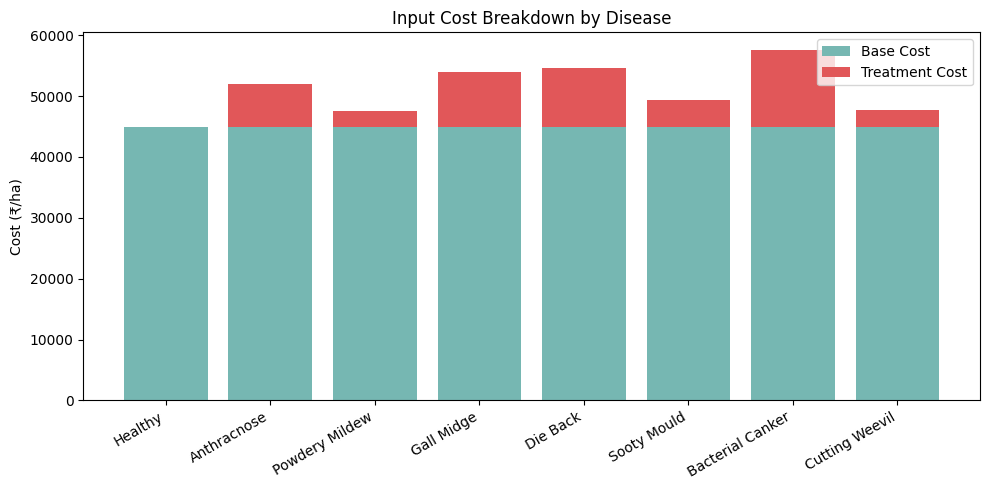

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
diseases = [r.disease for r in reports]
base_costs = [r.input_cost for r in reports]
treat_costs = [r.treatment_cost for r in reports]

ax.bar(diseases, base_costs, label='Base Cost', color='#76B7B2')
ax.bar(diseases, treat_costs, bottom=base_costs, label='Treatment Cost', color='#E15759')
ax.set_ylabel('Cost (₹/ha)')
ax.set_title('Input Cost Breakdown by Disease')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('reports/figures/cost_breakdown.png', dpi=150)
print("Saved cost_breakdown.png")

## 6. Decision Logic Summary

| Grade | Condition | Recommendation |
|---|---|---|
| A | Severity < 0.5 | Market (export quality) |
| B | Severity 0.5-1.5 | Market if revenue > pulp |
| C | Severity 1.5-2.5 | Pulp factory |
| D | Severity > 2.5 | Reject / compost |

**Key insight**: Disease severity directly controls the market/pulp decision.
Phase 3 disease detection → Phase 4 yield prediction → Phase 5 economic decision.

## 7. Sensitivity: Severity vs Net Revenue

Saved severity_revenue_curve.png


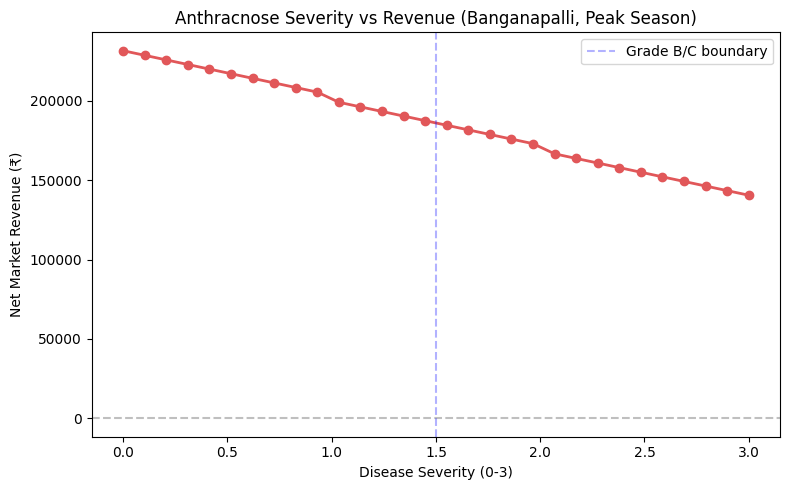

In [8]:
severities = np.linspace(0, 3, 30)
revenues = []
for s in severities:
    r = generate_report('Anthracnose', s, 8.0, 'Banganapalli', 'peak')
    revenues.append(r.net_revenue_market)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(severities, revenues, 'o-', color='#E15759', linewidth=2)
ax.set_xlabel('Disease Severity (0-3)')
ax.set_ylabel('Net Market Revenue (₹)')
ax.set_title('Anthracnose Severity vs Revenue (Banganapalli, Peak Season)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=1.5, color='blue', linestyle='--', alpha=0.3, label='Grade B/C boundary')
ax.legend()
plt.tight_layout()
plt.savefig('reports/figures/severity_revenue_curve.png', dpi=150)
print("Saved severity_revenue_curve.png")